# Merge biological replicates of image batches

In [1]:
# imports
import os
import re
import shutil
import glob
from tqdm import tqdm
import numpy as np
import polars as pl
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Cell crop QC

Visualize the cell crops from random alleles to see if they are valid cells that could be used for training later.

In [2]:
def channel_to_cmap(channel):
    if channel == "pro":
        cmap = mpl.colors.LinearSegmentedColormap.from_list("green_cmap", ["#000","#65fe08"])
    elif channel == "nuc":
        cmap = mpl.colors.LinearSegmentedColormap.from_list("green_cmap", ["#000","#0000FF"])
    # elif channel == "Mito":
    #     cmap = mpl.colors.LinearSegmentedColormap.from_list("green_cmap", ["#000","#FF0000"]) 
    # elif channel == "AGP":
    #     cmap = mpl.colors.LinearSegmentedColormap.from_list("green_cmap", ["#000","#FFFF00"]) 
    else:
        cmap = "gray"
    return cmap


def viz_cell_crop(img_arr, cell_comp, max_intensity=.99, ax=None, axis_off=True):
    cmap = channel_to_cmap(cell_comp)
    if ax is None:
        plt.imshow(img_arr, vmin=0, vmax=np.percentile(img_arr, max_intensity*100), cmap=cmap)
        if axis_off:
            plt.axis('off')  # Turn off axis labels
        plt.show()
    else:
        ax.imshow(img_arr, vmin=0, vmax=np.percentile(img_arr, max_intensity*100), cmap=cmap)
        if axis_off:
            ax.axis('off')
        plot_label = f"s2n ratio:\n{np.percentile(img_arr, 99) / np.percentile(img_arr, 25):.3f}"
        ax.text(0.05, 0.95, plot_label, color='white', fontsize=9,
                verticalalignment='top', horizontalalignment='left', 
                transform=ax.transAxes,
                bbox=dict(facecolor='black', alpha=0.2, linewidth=1))

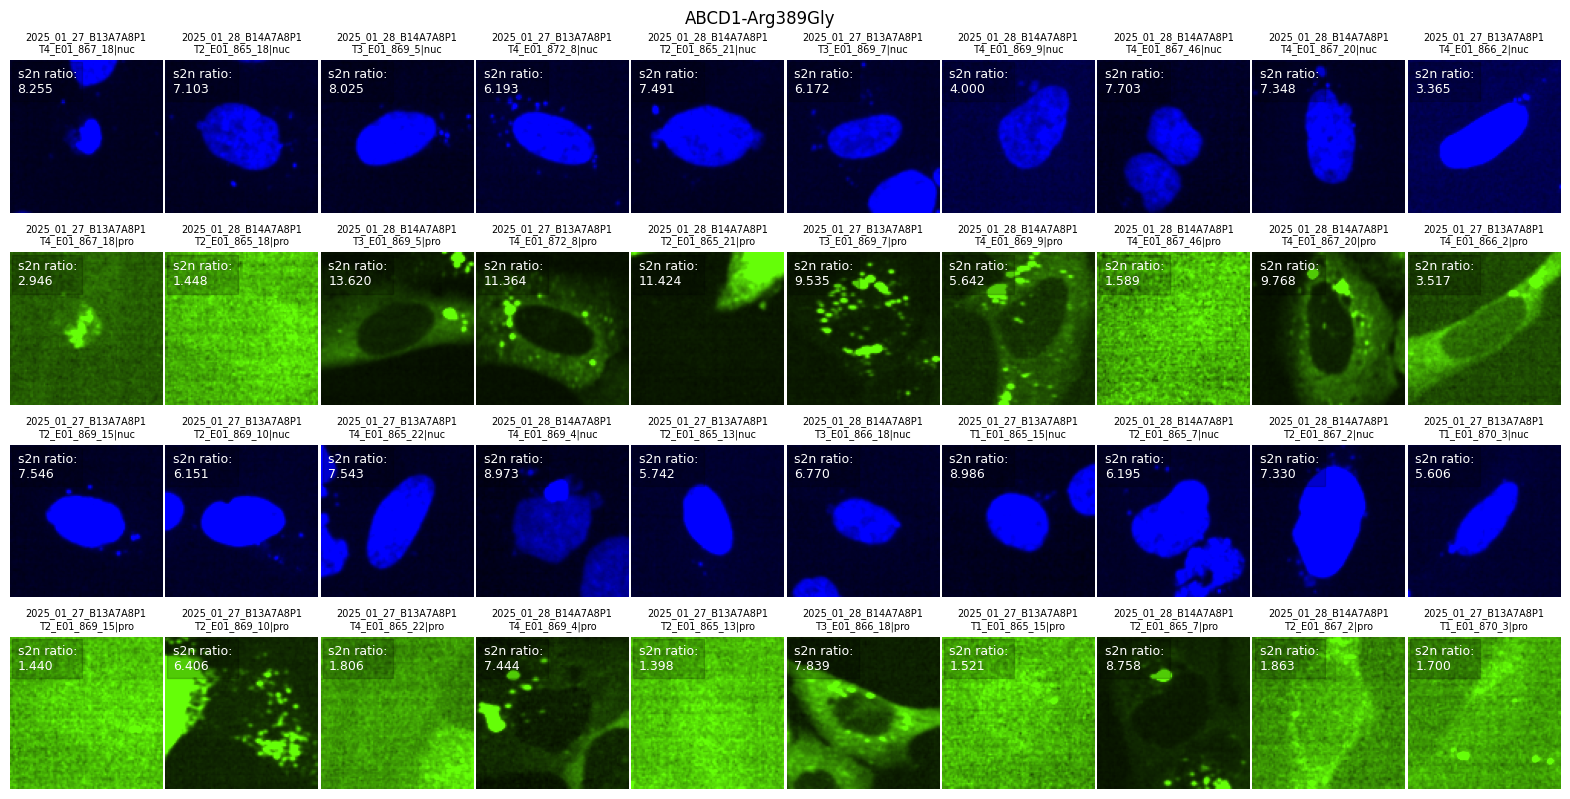

In [3]:
# Compare this to the example data structure
# Meta has #cells X 3 columns, each of three imaging npy have #cells X 100x100 pixels
# Need to find out if the pipeline will accept the concatenated data or if I need to split it & format like sample data in order to train the model. 
# 
# "CTCF", "CTCF-Arg567Trp"
for gene_allele in ["ABCD1-Arg389Gly"]:
    ex_meta = np.load(f"../data/interim/3_model_input/2025_07_B78-1112-1314-1516/{gene_allele}_label.npy", allow_pickle=True)
    ex_nuc = np.load(f"../data/interim/3_model_input/2025_07_B78-1112-1314-1516/{gene_allele}_nuc.npy", allow_pickle=True)
    ex_prot = np.load(f"../data/interim/3_model_input/2025_07_B78-1112-1314-1516/{gene_allele}_pro.npy", allow_pickle=True)
    replace = not (ex_meta.shape[0]>=20)
    random_cells = np.random.choice(np.arange(ex_meta.shape[0]), 20, replace=replace)
    
    fig, axes = plt.subplots(4, 10, figsize=(20, 10))
    for idx, cell in enumerate(random_cells):
        # print(idx)
        if idx < 10:
            ## plot nuc
            viz_cell_crop(ex_nuc[cell,:,:], "nuc", ax=axes[idx // 10, idx % 10])
            viz_cell_crop(ex_prot[cell,:,:], "pro", ax=axes[idx // 10 + 1, idx % 10])
            axes[idx // 10, idx % 10].set_title("\n".join([ex_meta[cell,1].split("_T")[0], "T"+ex_meta[cell,1].split("_T")[1]+"|nuc"]), fontsize=7)
            axes[idx // 10 + 1, idx % 10].set_title("\n".join([ex_meta[cell,1].split("_T")[0], "T"+ex_meta[cell,1].split("_T")[1]+"|pro"]), fontsize=7)
        else:
            ## plot nuc
            viz_cell_crop(ex_nuc[cell,:,:], "nuc", ax=axes[idx // 10 + 1, idx % 10])
            viz_cell_crop(ex_prot[cell,:,:], "pro", ax=axes[idx // 10 + 2, idx % 10])
            axes[idx // 10 + 1, idx % 10].set_title("\n".join([ex_meta[cell,1].split("_T")[0], "T"+ex_meta[cell,1].split("_T")[1]+"|nuc"]), fontsize=7)
            axes[idx // 10 + 2, idx % 10].set_title("\n".join([ex_meta[cell,1].split("_T")[0], "T"+ex_meta[cell,1].split("_T")[1]+"|pro"]), fontsize=7)
    fig.suptitle(gene_allele, y=0.92)
    fig.subplots_adjust(wspace=.02, hspace=-.1, top=.9)

## 2. Merge across multiple directories

In [7]:
# Helper function to get allele file mapping for a directory.
def get_allele_files(dir_path):
    """
    Returns a dict mapping allele -> {file_type: full_path}.
    Expected file pattern: {allele}_{file_type}.npy, where file_type is label, pro, or nuc.
    """
    allele_files = {}
    pattern = re.compile(r'^(?P<allele>.+)_(?P<type>label|pro|nuc)\.npy$')
    for filename in os.listdir(dir_path):
        if filename.endswith('.npy'):
            match = pattern.match(filename)
            if match:
                allele = match.group("allele")
                file_type = match.group("type")
                allele_files.setdefault(allele, {})[file_type] = os.path.join(dir_path, filename)
            else:
                print(f"Warning: {filename} in {dir_path} does not match expected pattern")
    return allele_files


# List of directories to merge
# dirs_to_merge = [
#     "../data/interim/3_model_input/2024_01_23_Batch_7",
#     "../data/interim/3_model_input/2024_02_06_Batch_8",
#     "../data/interim/3_model_input/2024_12_09_Batch_11",
#     "../data/interim/3_model_input/2024_12_09_Batch_12",
#     "../data/interim/3_model_input/2025_01_27_Batch_13",
#     "../data/interim/3_model_input/2025_01_28_Batch_14",
#     "../data/interim/3_model_input/2025_03_17_Batch_15",
#     "../data/interim/3_model_input/2025_03_17_Batch_16",
# ]

# merged_dir = "../data/interim/3_model_input/2025_07_B78-1112-1314-1516"
# Ensure merged_dir exists
# os.makedirs(merged_dir, exist_ok=True)

In [ ]:
# final_total_cells = 0
# for batch_dir in dirs_to_merge:
#     # Get file mappings from both directories.
#     allele_files = get_allele_files(batch_dir)
#     alleles = set(allele_files.keys())
#     # Expected file types for each allele
#     expected_types = ["label", "pro", "nuc"]
#     total_cells = 0
#     for allele in sorted(alleles):
#         for file_type in expected_types:
#             path1 = allele_files[allele][file_type]
#             arr1 = np.load(path1, allow_pickle=True)
#             if file_type == "label":
#                 cell_num_1 = arr1.shape[0]
#                 assert arr1.shape[1] == 2
#             else:
#                 assert arr1.shape[0] == cell_num_1
#         total_cells += arr1.shape[0]
#     print(batch_dir, total_cells)
#     final_total_cells += total_cells
# print("Final total cells:", final_total_cells)

In [2]:
# Collect allele files from all directories
allele_files_list = [get_allele_files(dir_path) for dir_path in dirs_to_merge]

# Determine the union of alleles across all directories
all_alleles = set()
for allele_files in allele_files_list:
    all_alleles.update(allele_files.keys())

# Expected file types for each allele
expected_types = ["label", "pro", "nuc"]

# Initialize counters
total_cells = 0
cells_per_dir = [0] * len(dirs_to_merge)

# Merge files for each allele
for allele in tqdm(sorted(all_alleles)):
    merged_data = {file_type: [] for file_type in expected_types}

    # Iterate through each directory and collect data for the current allele
    for i, allele_files in enumerate(allele_files_list):
        if allele in allele_files:
            for file_type in expected_types:
                if file_type in allele_files[allele]:
                    path = allele_files[allele][file_type]
                    arr = np.load(path, allow_pickle=True)
                    merged_data[file_type].append(arr)
                    if file_type == "label":
                        cell_num = arr.shape[0]
                        cells_per_dir[i] += cell_num

    # Concatenate data across all directories for the current allele
    for file_type, arrays in merged_data.items():
        if arrays:  # Only process if data exists for this file type
            merged_arr = np.concatenate(arrays, axis=0)
            out_filename = f"{allele}_{file_type}.npy"
            out_path = os.path.join(merged_dir, out_filename)

            if file_type == "label":
                assert merged_arr.shape[1] == 2, f"{allele} label shape mismatch"
            else:
                assert merged_arr.shape[1:] == (100, 100), f"{allele} crop dim mismatch"

            np.save(out_path, merged_arr)
            # print(f"Merged {file_type} for allele {allele} into {out_path}")

    # Update total cell count
    total_cells += merged_arr.shape[0]

# Print summary
print(f"Total cells merged: {total_cells}")
for i, dir_path in enumerate(dirs_to_merge):
    print(f"Cells from {dir_path}: {cells_per_dir[i]}")

100%|██████████| 1454/1454 [13:51<00:00,  1.75it/s] 

Total cells merged: 2476599
Cells from ../inputs/1_model_input/2024_01_23_Batch_7: 598370
Cells from ../inputs/1_model_input/2024_02_06_Batch_8: 96362
Cells from ../inputs/1_model_input/2024_12_09_Batch_11: 139505
Cells from ../inputs/1_model_input/2024_12_09_Batch_12: 118639
Cells from ../inputs/1_model_input/2025_01_27_Batch_13: 455387
Cells from ../inputs/1_model_input/2025_01_28_Batch_14: 434451
Cells from ../inputs/1_model_input/2025_03_17_Batch_15: 290807
Cells from ../inputs/1_model_input/2025_03_17_Batch_16: 343078


## 3. Add an extra qc step

```python ../scripts/filter_cells_by_s2n_fast.py```

In [25]:
cell_counts_allele = []
for f in glob.glob("../data/interim/3_model_input/2025_07_B78-1112-1314-1516_clean/*_pro.npy"):
    arr = np.load(f, allow_pickle=True)
    cell_counts_allele.append(arr.shape[0])

In [26]:
np.mean(cell_counts_allele), np.std(cell_counts_allele)

(np.float64(1567.0852819807428), np.float64(2282.039782835441))

In [27]:
len(glob.glob("../data/interim/3_model_input/2025_07_B78-1112-1314-1516_clean/*_label.npy"))

1454

Text(0, 0.5, 'Number of Cells per Allele')

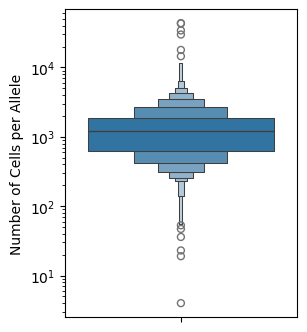

In [30]:
import seaborn as sns
fig, ax = plt.subplots(1,1, figsize=(3,4))
sns.boxenplot(cell_counts_allele, ax=ax)
ax.set_yscale("log")
ax.set_ylabel("Number of Cells per Allele")

In [16]:
# # Compare this to the example data structure
# # Meta has #cells X 3 columns, each of three imaging npy have #cells X 100x100 pixels
# # Need to find out if the pipeline will accept the concatenated data or if I need to split it & format like sample data in order to train the model. 

# for gene_allele in ["AGXT-Ile202Asn", "AGXT", "AGXT-Gly116Arg", "AGXT-Asp201Asn", "AGXT-Ser218Leu"]:
#     ex_meta = np.load(f"../inputs/1_model_input/2025_07_B78-1112-1314-1516_clean/{gene_allele}_label.npy", allow_pickle=True)
#     ex_nuc = np.load(f"../inputs/1_model_input/2025_07_B78-1112-1314-1516_clean/{gene_allele}_nuc.npy", allow_pickle=True)
#     ex_prot = np.load(f"../inputs/1_model_input/2025_07_B78-1112-1314-1516_clean/{gene_allele}_pro.npy", allow_pickle=True)
#     replace = not (ex_meta.shape[0]>=20)
#     random_cells = np.random.choice(np.arange(ex_meta.shape[0]), 20, replace=replace)
#     # print(ex_meta)
#     # print(random_cells)
#     fig, axes = plt.subplots(4, 10, figsize=(20, 10))
#     for idx, cell in enumerate(random_cells):
#         # print(idx)
#         if idx < 10:
#             ## plot nuc
#             viz_cell_crop(ex_nuc[cell,:,:], "nuc", ax=axes[idx // 10, idx % 10])
#             viz_cell_crop(ex_prot[cell,:,:], "pro", ax=axes[idx // 10 + 1, idx % 10])
#             axes[idx // 10, idx % 10].set_title("\n".join([ex_meta[cell,1].split("_T")[0], "T"+"|nuc"]), fontsize=7) ## +ex_meta[cell,1].split("_T")[1]
#             axes[idx // 10 + 1, idx % 10].set_title("\n".join([ex_meta[cell,1].split("_T")[0], "T"+"|pro"]), fontsize=7) ##+ex_meta[cell,1].split("_T")[1]
#         else:
#             ## plot nuc
#             viz_cell_crop(ex_nuc[cell,:,:], "nuc", ax=axes[idx // 10 + 1, idx % 10])
#             viz_cell_crop(ex_prot[cell,:,:], "pro", ax=axes[idx // 10 + 2, idx % 10])
#             axes[idx // 10 + 1, idx % 10].set_title("\n".join([ex_meta[cell,1].split("_T")[0], "T"+"|nuc"]), fontsize=7) ##+ex_meta[cell,1].split("_T")[1]
#             axes[idx // 10 + 2, idx % 10].set_title("\n".join([ex_meta[cell,1].split("_T")[0], "T"+"|pro"]), fontsize=7) ##+ex_meta[cell,1].split("_T")[1]
#     fig.suptitle(gene_allele, y=0.92)
#     fig.subplots_adjust(wspace=.02, hspace=-.1, top=.9)

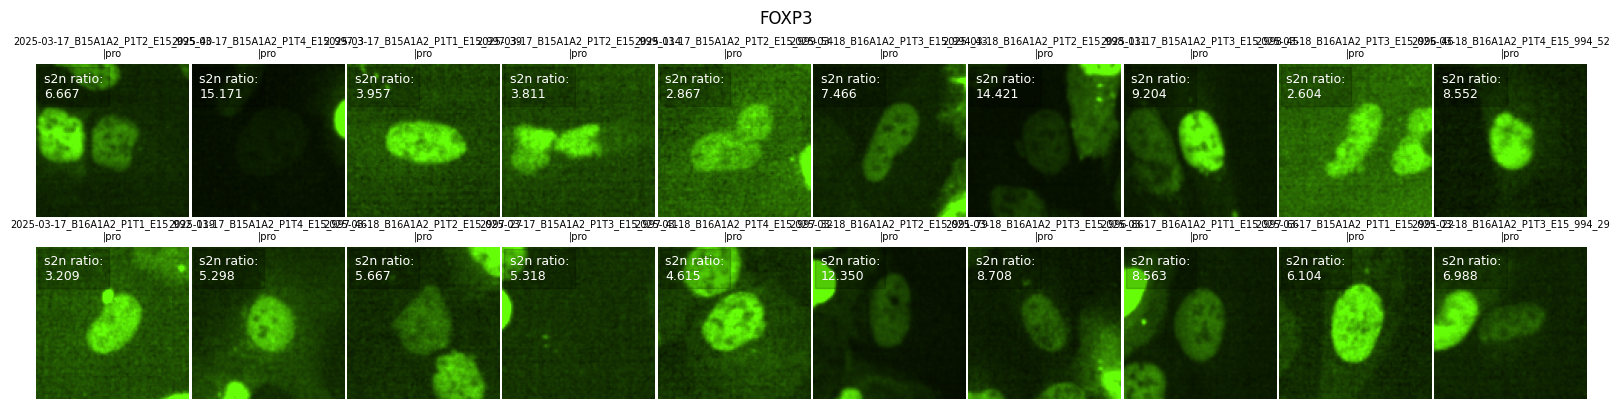

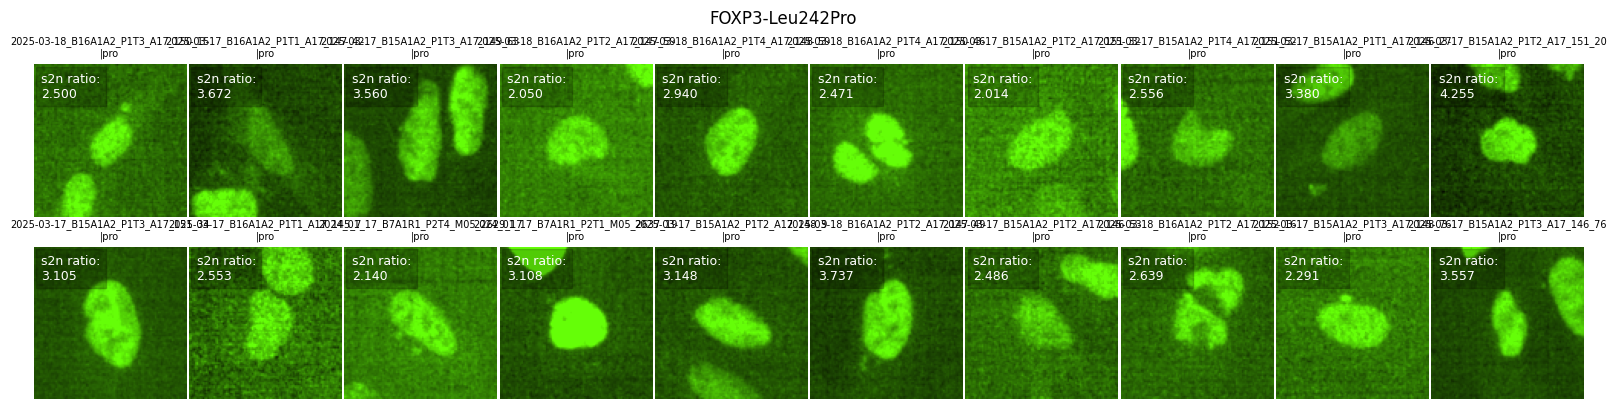

In [14]:
# Compare this to the example data structure
# Meta has #cells X 3 columns, each of three imaging npy have #cells X 100x100 pixels
# Need to find out if the pipeline will accept the concatenated data or if I need to split it & format like sample data in order to train the model. 

# for gene_allele in ["RHO", "RHO-Asp190Gly", "RHO-Cys110Tyr", "RHO-Arg135Trp"]: ##, "AGXT-Ile202Asn", "AGXT-Gly116Arg", "AGXT-Asp201Asn", "AGXT-Ser218Leu"
## RAD51D: "RAD51D",'RAD51D-Glu233Gly',
# 'RAD51D-Ala231Ser',
# 'RAD51D-Glu307Lys',
# 'RAD51D-Ile251Val',
# 'RAD51D-Val132Ile',
# 'RAD51D-Arg55Trp',
# 'RAD51D-Cys9Ser',
# 'RAD51D-Val66Met',
# 'RAD51D-His23Arg',
# 'RAD51D-Gly289Ser',
# 'RAD51D-Phe305Leu',
# 'RAD51D-Asn138His',
# 'RAD51D-Thr328Ile',
# 'RAD51D-Val28Leu',
# 'RAD51D-Ser46Cys',
# 'RAD51D-Met308Val',
# 'RAD51D-Val66Leu',
# 'RAD51D-Ile17Val',
# 'RAD51D-Val56Gly'
# ['G6PD', 'G6PD-Glu398Lys', 'G6PD-Ile48Thr', 'G6PD-Arg365His', 'G6PD-Gly378Ser']
for gene_allele in ["FOXP3", "FOXP3-Leu242Pro"]:
    ex_meta = np.load(f"../data/interim/3_model_input/2025_07_B78-1112-1314-1516_clean/{gene_allele}_label.npy", allow_pickle=True)
    ex_nuc = np.load(f"../data/interim/3_model_input/2025_07_B78-1112-1314-1516_clean/{gene_allele}_nuc.npy", allow_pickle=True)
    ex_prot = np.load(f"../data/interim/3_model_input/2025_07_B78-1112-1314-1516_clean/{gene_allele}_pro.npy", allow_pickle=True)
    replace = not (ex_meta.shape[0]>=20)
    random_cells = np.random.choice(np.arange(ex_meta.shape[0]), 20, replace=replace)
    fig, axes = plt.subplots(2, 10, figsize=(20,5))
    for idx, cell in enumerate(random_cells):
        viz_cell_crop(ex_prot[cell,:,:], "pro", ax=axes[idx // 10, idx % 10])
        axes[idx // 10, idx % 10].set_title("\n".join([ex_meta[cell,1].split("_T")[0], "|pro"]), fontsize=7) ## "T"+ex_meta[cell,1].split("_T")[1]+
        # if idx < 10:
        #     ## plot nuc
        #     # viz_cell_crop(ex_nuc[cell,:,:], "pro", ax=axes[idx // 10, idx % 10])
        #     viz_cell_crop(ex_prot[cell,:,:], "pro", ax=axes[idx // 10, idx % 10])
        #     # axes[idx // 10, idx % 10].set_title("\n".join([ex_meta[cell,1].split("_T")[0], "T"+"|nuc"]), fontsize=7) ## +ex_meta[cell,1].split("_T")[1]
        #     # axes[idx // 10 + 1, idx % 10].set_title("\n".join([ex_meta[cell,1].split("_T")[0], "T"+"|pro"]), fontsize=7) ##+ex_meta[cell,1].split("_T")[1]
        # else:
        #     ## plot nuc
        #     # viz_cell_crop(ex_nuc[cell,:,:], "pro", ax=axes[idx // 10, idx % 10])
        #     viz_cell_crop(ex_prot[cell,:,:], "pro", ax=axes[idx // 10, idx % 10])
            # axes[idx // 10 + 1, idx % 10].set_title("\n".join([ex_meta[cell,1].split("_T")[0], "T"+"|nuc"]), fontsize=7) ##+ex_meta[cell,1].split("_T")[1]
            # axes[idx // 10 + 2, idx % 10].set_title("\n".join([ex_meta[cell,1].split("_T")[0], "T"+"|pro"]), fontsize=7) ##+ex_meta[cell,1].split("_T")[1]
    fig.suptitle(gene_allele, y=0.9)
    fig.subplots_adjust(wspace=.02, hspace=0.12, top=.8)

## Examine the number of cell crops per each batch (biological replicates)

In [ ]:
# Get file mappings from both directories.
allele_files = get_allele_files(dir_1)
alleles = set(allele_files.keys())
# Expected file types for each allele
expected_types = ["label", "pro", "nuc"]

total_cells = 0
for allele in sorted(alleles):
    for file_type in expected_types:
        path1 = allele_files[allele][file_type]
        arr1 = np.load(path1, allow_pickle=True)
        
        if file_type == "label":
            cell_num_1 = arr1.shape[0]
            assert arr1.shape[1] == 2
        else:
            assert arr1.shape[0] == cell_num_1
    total_cells += arr1.shape[0]
    
print(total_cells)

705310


In [ ]:
# Get file mappings from both directories.
allele_files = get_allele_files(dir_2)
alleles = set(allele_files.keys())
# Expected file types for each allele
expected_types = ["label", "pro", "nuc"]

total_cells = 0
for allele in sorted(alleles):
    for file_type in expected_types:
        path1 = allele_files[allele][file_type]
        arr1 = np.load(path1, allow_pickle=True)
        
        if file_type == "label":
            cell_num_1 = arr1.shape[0]
            assert arr1.shape[1] == 2
        else:
            assert arr1.shape[0] == cell_num_1
    total_cells += arr1.shape[0]
    
print(total_cells)

110912


### Merge two batches

In [3]:
# # Get file mappings from both directories.
# allele_files1 = get_allele_files(dir_1)
# allele_files2 = get_allele_files(dir_2)

# # Determine the union of alleles across both directories.
# alleles = set(allele_files1.keys()) | set(allele_files2.keys())

# # Expected file types for each allele
# expected_types = ["label", "pro", "nuc"]

# # print(allele_files1)
# # print(allele_files2)

# cells_dir1, cells_dir2, total_cells = 0, 0, 0

# for allele in sorted(alleles):
#     # Check for missing files in each directory that contains the allele.
#     if allele in allele_files1:
#         files1 = allele_files1[allele]
#         missing = expected_types - files1.keys()
#         if missing:
#             raise Exception(f"Allele {allele} in {dir_1} is missing files: {missing}")
#     if allele in allele_files2:
#         files2 = allele_files2[allele]
#         missing = expected_types - files2.keys()
#         if missing:
#             raise Exception(f"Allele {allele} in {dir_2} is missing files: {missing}")
    
#     # If allele exists in both directories, stack the arrays.
#     if allele in allele_files1 and allele in allele_files2:
#         for file_type in expected_types:
#             path1 = allele_files1[allele][file_type]
#             path2 = allele_files2[allele][file_type]
#             arr1 = np.load(path1, allow_pickle=True)
#             arr2 = np.load(path2, allow_pickle=True)
#             merged_arr = np.concatenate([arr1, arr2], axis=0)
#             out_filename = f"{allele}_{file_type}.npy"
#             out_path = os.path.join(merged_dir, out_filename)
            
#             if file_type == "label":
#                 cell_num_1, cell_num_2 = arr1.shape[0], arr2.shape[0]
#                 assert merged_arr.shape[1] == 2
#                 print(f"Stacked {os.path.basename(path1)} {os.path.basename(path2)} to {out_path}")
#             else:
#                 assert merged_arr.shape[1] == 100 and merged_arr.shape[2] == 100, f"{allele} cell crop dim. doesn't match"

#             assert merged_arr.shape[0] == (cell_num_1+cell_num_2), f"{allele} cell number doesn't match"
#             np.save(out_path, merged_arr)
        
#         cells_dir1 += cell_num_1
#         cells_dir2 += cell_num_2
#         total_cells += merged_arr.shape[0]

#     # If allele exists only in one directory, copy the files over.
#     else:
#         src_dir = dir_1 if allele in allele_files1 else dir_2
#         allele_files = allele_files1.get(allele, allele_files2.get(allele))
#         for file_type in expected_types:
#             src_path = allele_files[file_type]
#             arr1 = np.load(src_path, allow_pickle=True)
#             if file_type == "label":
#                 cell_num = arr1.shape[0]
#                 print(f"Copied {os.path.basename(src_path)} from {src_dir} to {dest_path}")
                    
#             dest_path = os.path.join(merged_dir, os.path.basename(src_path))
#             shutil.copy(src_path, dest_path)
            
#         if src_dir == dir_1:
#             cells_dir1 += cell_num
#         else:
#             cells_dir2 += cell_num

#         total_cells += cell_num

In [ ]:
# Get file mappings from both directories.
allele_files = get_allele_files(merged_dir)
alleles = set(allele_files.keys())

# Expected file types for each allele
expected_types = ["label", "pro", "nuc"]

total_cells = 0
for allele in sorted(alleles):
    for file_type in expected_types:
        path1 = allele_files[allele][file_type]
        arr1 = np.load(path1, allow_pickle=True)
        
        if file_type == "label":
            cell_num_1 = arr1.shape[0]
            assert arr1.shape[1] == 2
        else:
            assert arr1.shape[0] == cell_num_1
    total_cells += arr1.shape[0]
print(total_cells)

816222


In [ ]:
# 816222 - (669302 + 66931) # + 66931
# 79989 / 816222
# 66931 / 816222